# asses the history of runs


In [1]:
import sys
print(sys.executable)


import pandas as pd
%matplotlib inline

import matplotlib
print("backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt

import corner
import matplotlib.pyplot as plt



/home/kandrych/venvs/obriy311/bin/python
backend: module://matplotlib_inline.backend_inline


In [21]:
df=pd.read_csv("/fred/oz061/kandrych/smac/20260414_sed_corner_plot/smac_results/trials.csv")
results_dir="/fred/oz061/kandrych/smac/20260414_sed_corner_plot/smac_results/"
df

,alpha_viscosity,distance_pc,puffed_delta_r,puffed_h_rim_over_h0,puffed_r_rim,zone_1_Rc,zone_1_dust_mass,zone_1_flaring_exp,zone_1_gamma_exp,zone_1_gas_to_dust,...,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.001428,1220.0,11.410248,0.551950,11.867782,47.881610,0.001,1.412916,-1.947044,100.0,...,0.889045,0.201665,0.8,-0.006888,599,499561672,0.25,16.740249,36.733649,1
1,0.001428,1220.0,17.569861,0.552781,10.193069,49.888486,0.001,1.431301,-1.997107,100.0,...,0.892932,0.203187,0.8,-0.035960,524,499561672,0.25,17.432030,35.255185,1
2,0.001439,1220.0,10.891138,0.558642,11.867782,47.839307,0.001,1.406496,-1.890508,100.0,...,0.889086,0.201665,0.8,-0.044974,552,499561672,0.25,17.614995,63.380556,1
3,0.012289,1220.0,18.019150,0.451955,23.855605,49.344800,0.001,1.414886,-1.672930,100.0,...,0.984329,0.196732,0.7,-0.476610,388,499561672,0.25,17.641398,50.402253,1
4,0.001428,1220.0,17.529218,0.552781,11.876775,49.888486,0.001,1.422907,-1.879821,100.0,...,0.875355,0.191558,0.7,-0.040317,427,499561672,0.25,17.670455,49.097046,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,0.001084,1220.0,17.651176,1.238348,17.803591,24.981830,0.001,1.175910,-1.387250,50.0,...,0.497154,0.108855,0.7,-0.953010,14,499561672,0.25,780.568725,58.643349,1
696,0.054362,1220.0,7.950933,1.849749,31.853794,9.710993,0.002,1.000855,-1.608368,200.0,...,0.330271,0.618427,0.7,-1.092474,129,499561672,0.25,792.012891,252.451370,1
697,0.003670,1220.0,9.949629,0.637949,10.372550,46.988246,0.002,1.315675,-0.716546,100.0,...,0.321566,0.697076,0.7,-0.857696,95,499561672,0.25,871.463403,65.646839,1
698,0.010779,1220.0,18.150635,0.366559,17.389501,48.476288,0.002,1.571776,-0.920376,100.0,...,0.594351,0.600692,0.8,-1.157032,52,499561672,0.25,901.433664,62.353570,1


### Best configs table (at max budget)

In [22]:
top = df[df["budget"] == df["budget"].max()].nsmallest(5, "cost")
print("Top 5 max budget trials:")
top
#top.to_csv(results_dir / "top5_maxbudget.csv", index=False)



Top 5 max budget trials:


,alpha_viscosity,distance_pc,puffed_delta_r,puffed_h_rim_over_h0,puffed_r_rim,zone_1_Rc,zone_1_dust_mass,zone_1_flaring_exp,zone_1_gamma_exp,zone_1_gas_to_dust,...,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.001428,1220.0,11.410248,0.551950,11.867782,47.881610,0.001,1.412916,-1.947044,100.0,...,0.889045,0.201665,0.8,-0.006888,599,499561672,0.25,16.740249,36.733649,1
1,0.001428,1220.0,17.569861,0.552781,10.193069,49.888486,0.001,1.431301,-1.997107,100.0,...,0.892932,0.203187,0.8,-0.035960,524,499561672,0.25,17.432030,35.255185,1
2,0.001439,1220.0,10.891138,0.558642,11.867782,47.839307,0.001,1.406496,-1.890508,100.0,...,0.889086,0.201665,0.8,-0.044974,552,499561672,0.25,17.614995,63.380556,1
3,0.012289,1220.0,18.019150,0.451955,23.855605,49.344800,0.001,1.414886,-1.672930,100.0,...,0.984329,0.196732,0.7,-0.476610,388,499561672,0.25,17.641398,50.402253,1
4,0.001428,1220.0,17.529218,0.552781,11.876775,49.888486,0.001,1.422907,-1.879821,100.0,...,0.875355,0.191558,0.7,-0.040317,427,499561672,0.25,17.670455,49.097046,1


### Pairwise sanity checks (parameter vs cost)


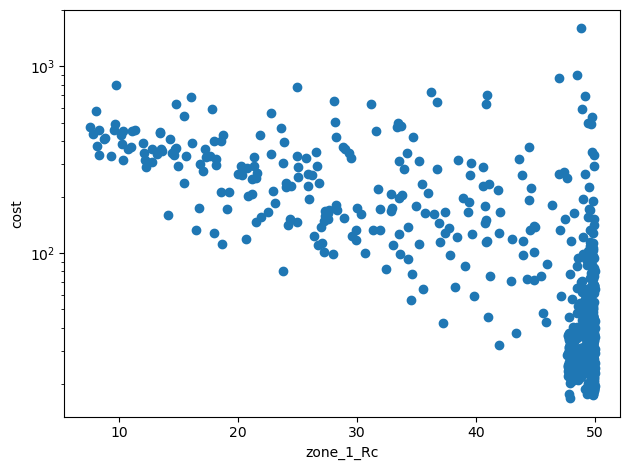

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [23]:


for p in ["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]:  # rename to your actual names
    if p in df.columns:
        plt.figure()
        plt.scatter(df[p], df["cost"])
        plt.xlabel(p); plt.ylabel("cost")
        plt.yscale("log")  # often helpful
        plt.tight_layout()
        plt.show()
        plt.savefig(results_dir / f"scatter_{p}.png", dpi=150)
        plt.close()


### Slice by budget (does the story change with fidelity?)

In [24]:
df.groupby("budget")["cost"].describe()#.to_csv(results_dir / "cost_by_budget.csv")


,count,mean,std,min,25%,50%,75%,max
budget,,,,,,,,
0.25,700.0,122.755859,159.967958,16.740249,26.84388,43.986218,160.866554,1597.842941


### Parameter importance (fast, practical)

In [6]:
def binned_medians(df, param, bins=2):
    s = df[[param, "cost"]].dropna()
    s["bin"] = pd.qcut(s[param], q=bins, duplicates="drop")
    return s.groupby("bin", observed=True)["cost"].median().sort_values()

for p in ["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]:
    if p in df.columns:
        bm = binned_medians(df[df["budget"] == df["budget"].max()], p)
        print(f"Binned medians for {p}:")
        print(bm)
        #bm.to_csv(results_dir / f"binned_median_{p}.csv")


Binned medians for zone_1_Rc:
bin
(48.96, 49.996]                 31.960694
(7.5249999999999995, 48.96]    143.475306
Name: cost, dtype: float64
Binned medians for zone_1_flaring_exp:
bin
(1.415, 1.599]                 34.607267
(0.9999999999999999, 1.415]    73.236147
Name: cost, dtype: float64
Binned medians for zone_1_dust_mass:
bin
(0.0, 0.004]    43.986218
Name: cost, dtype: float64
Binned medians for zone_1_species_1_porosity:
bin
(0.0016099999999999999, 0.209]     29.416453
(0.209, 0.798]                    114.048073
Name: cost, dtype: float64


### Clustering of “good” solutions (degeneracies)

In [25]:
good = df[df["budget"] == df["budget"].max()].nsmallest(5, "cost")
good.describe()#.to_csv(results_dir / "good5_summary.csv")

,alpha_viscosity,distance_pc,puffed_delta_r,puffed_h_rim_over_h0,puffed_r_rim,zone_1_Rc,zone_1_dust_mass,zone_1_flaring_exp,zone_1_gamma_exp,zone_1_gas_to_dust,...,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
count,5.000000,5.0,5.000000,5.000000,5.000000,5.000000,5.000,5.000000,5.000000,5.0,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.0,5.00,5.000000,5.000000,5.0
mean,0.003602,1220.0,15.083923,0.533622,13.932202,48.968537,0.001,1.417701,-1.877482,100.0,...,0.906149,0.198961,0.760000,-0.120950,498.000000,499561672.0,0.25,17.419825,46.973738,1.0
std,0.004856,0.0,3.600356,0.045732,5.594718,1.035707,0.000,0.009597,0.123659,0.0,...,0.044212,0.004802,0.054772,0.199375,87.940321,0.0,0.00,0.391144,11.485107,0.0
min,0.001428,1220.0,10.891138,0.451955,10.193069,47.839307,0.001,1.406496,-1.997107,100.0,...,0.875355,0.191558,0.700000,-0.476610,388.000000,499561672.0,0.25,16.740249,35.255185,1.0
25%,0.001428,1220.0,11.410248,0.551950,11.867782,47.881610,0.001,1.412916,-1.947044,100.0,...,0.889045,0.196732,0.700000,-0.044974,427.000000,499561672.0,0.25,17.432030,36.733649,1.0
50%,0.001428,1220.0,17.529218,0.552781,11.867782,49.344800,0.001,1.414886,-1.890508,100.0,...,0.889086,0.201665,0.800000,-0.040317,524.000000,499561672.0,0.25,17.614995,49.097046,1.0
75%,0.001439,1220.0,17.569861,0.552781,11.876775,49.888486,0.001,1.422907,-1.879821,100.0,...,0.892932,0.201665,0.800000,-0.035960,552.000000,499561672.0,0.25,17.641398,50.402253,1.0
max,0.012289,1220.0,18.019150,0.558642,23.855605,49.888486,0.001,1.431301,-1.672930,100.0,...,0.984329,0.203187,0.800000,-0.006888,599.000000,499561672.0,0.25,17.670455,63.380556,1.0


### Plot

In [26]:
curve = df.groupby(["config_id", "budget"])["cost"].min().reset_index()
curve#.to_csv(results_dir / "learning_curves.csv", index=False)


,config_id,budget,cost
0,1,0.25,161.863871
1,2,0.25,346.286426
2,3,0.25,132.701223
3,4,0.25,348.442194
4,5,0.25,370.394003
...,...,...,...
695,696,0.25,21.903734
696,697,0.25,29.591104
697,698,0.25,21.484249
698,699,0.25,35.750915


## For the cornerplot


SMAC does not give a true posterior.
Your corner plot represents a high-likelihood region sampled by Bayesian optimisation, not an MCMC posterior.

This is perfectly acceptable if you phrase it as:

“distribution of high-performing models”

In [27]:
# Restrict to highest fidelity
df_max = df[df["budget"] == df["budget"].max()].copy()

# Drop failed / NaN
df_max = df_max.dropna(subset=["cost"])

# Optional: keep only the best 30% of trials
q = 0.9
cost_cut = df_max["cost"].quantile(q)
df_sel = df_max[df_max["cost"] <= cost_cut]


In [28]:
exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc', "alpha_viscosity", 'zone_1_gas_to_dust', 'zone_1_species_1_amin'}

param_cols = [c for c in df_sel.columns if c not in exclude]
param_cols


['puffed_delta_r',
 'puffed_h_rim_over_h0',
 'puffed_r_rim',
 'zone_1_Rc',
 'zone_1_dust_mass',
 'zone_1_flaring_exp',
 'zone_1_gamma_exp',
 'zone_1_scale_height',
 'zone_1_species_1_porosity',
 'zone_1_species_1_volume_fraction',
 'zone_1_surface_density_exp']

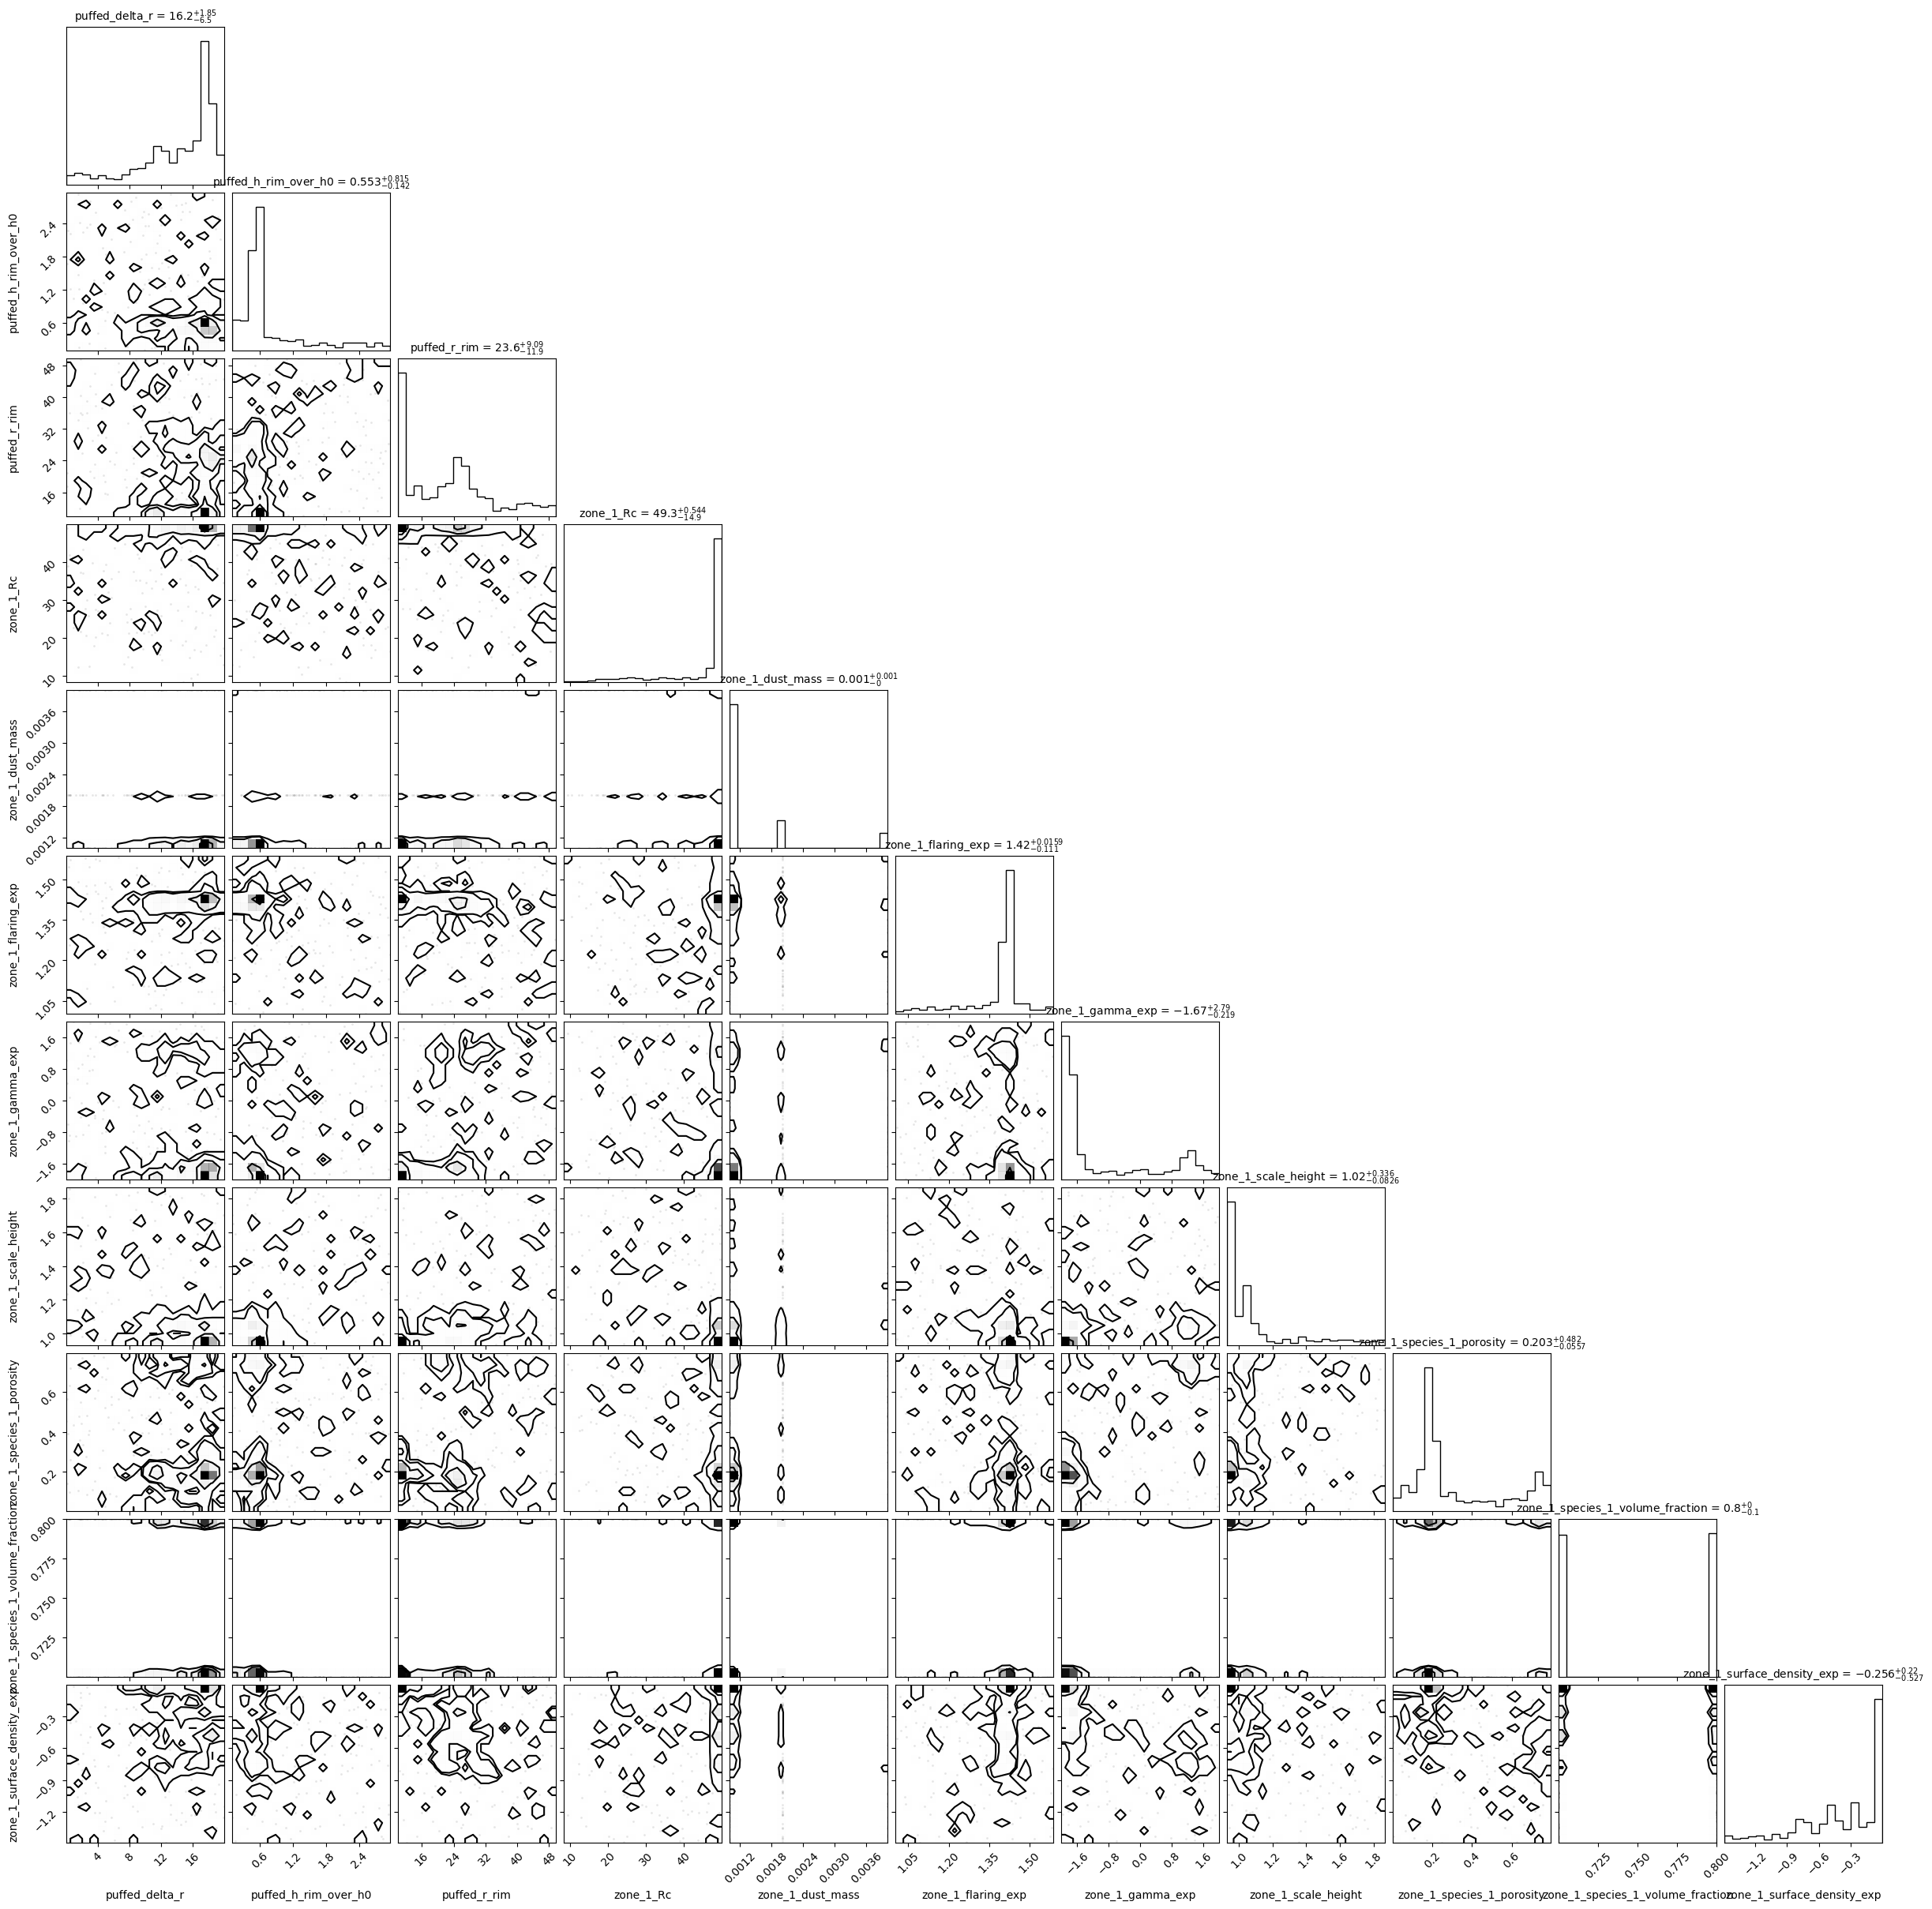

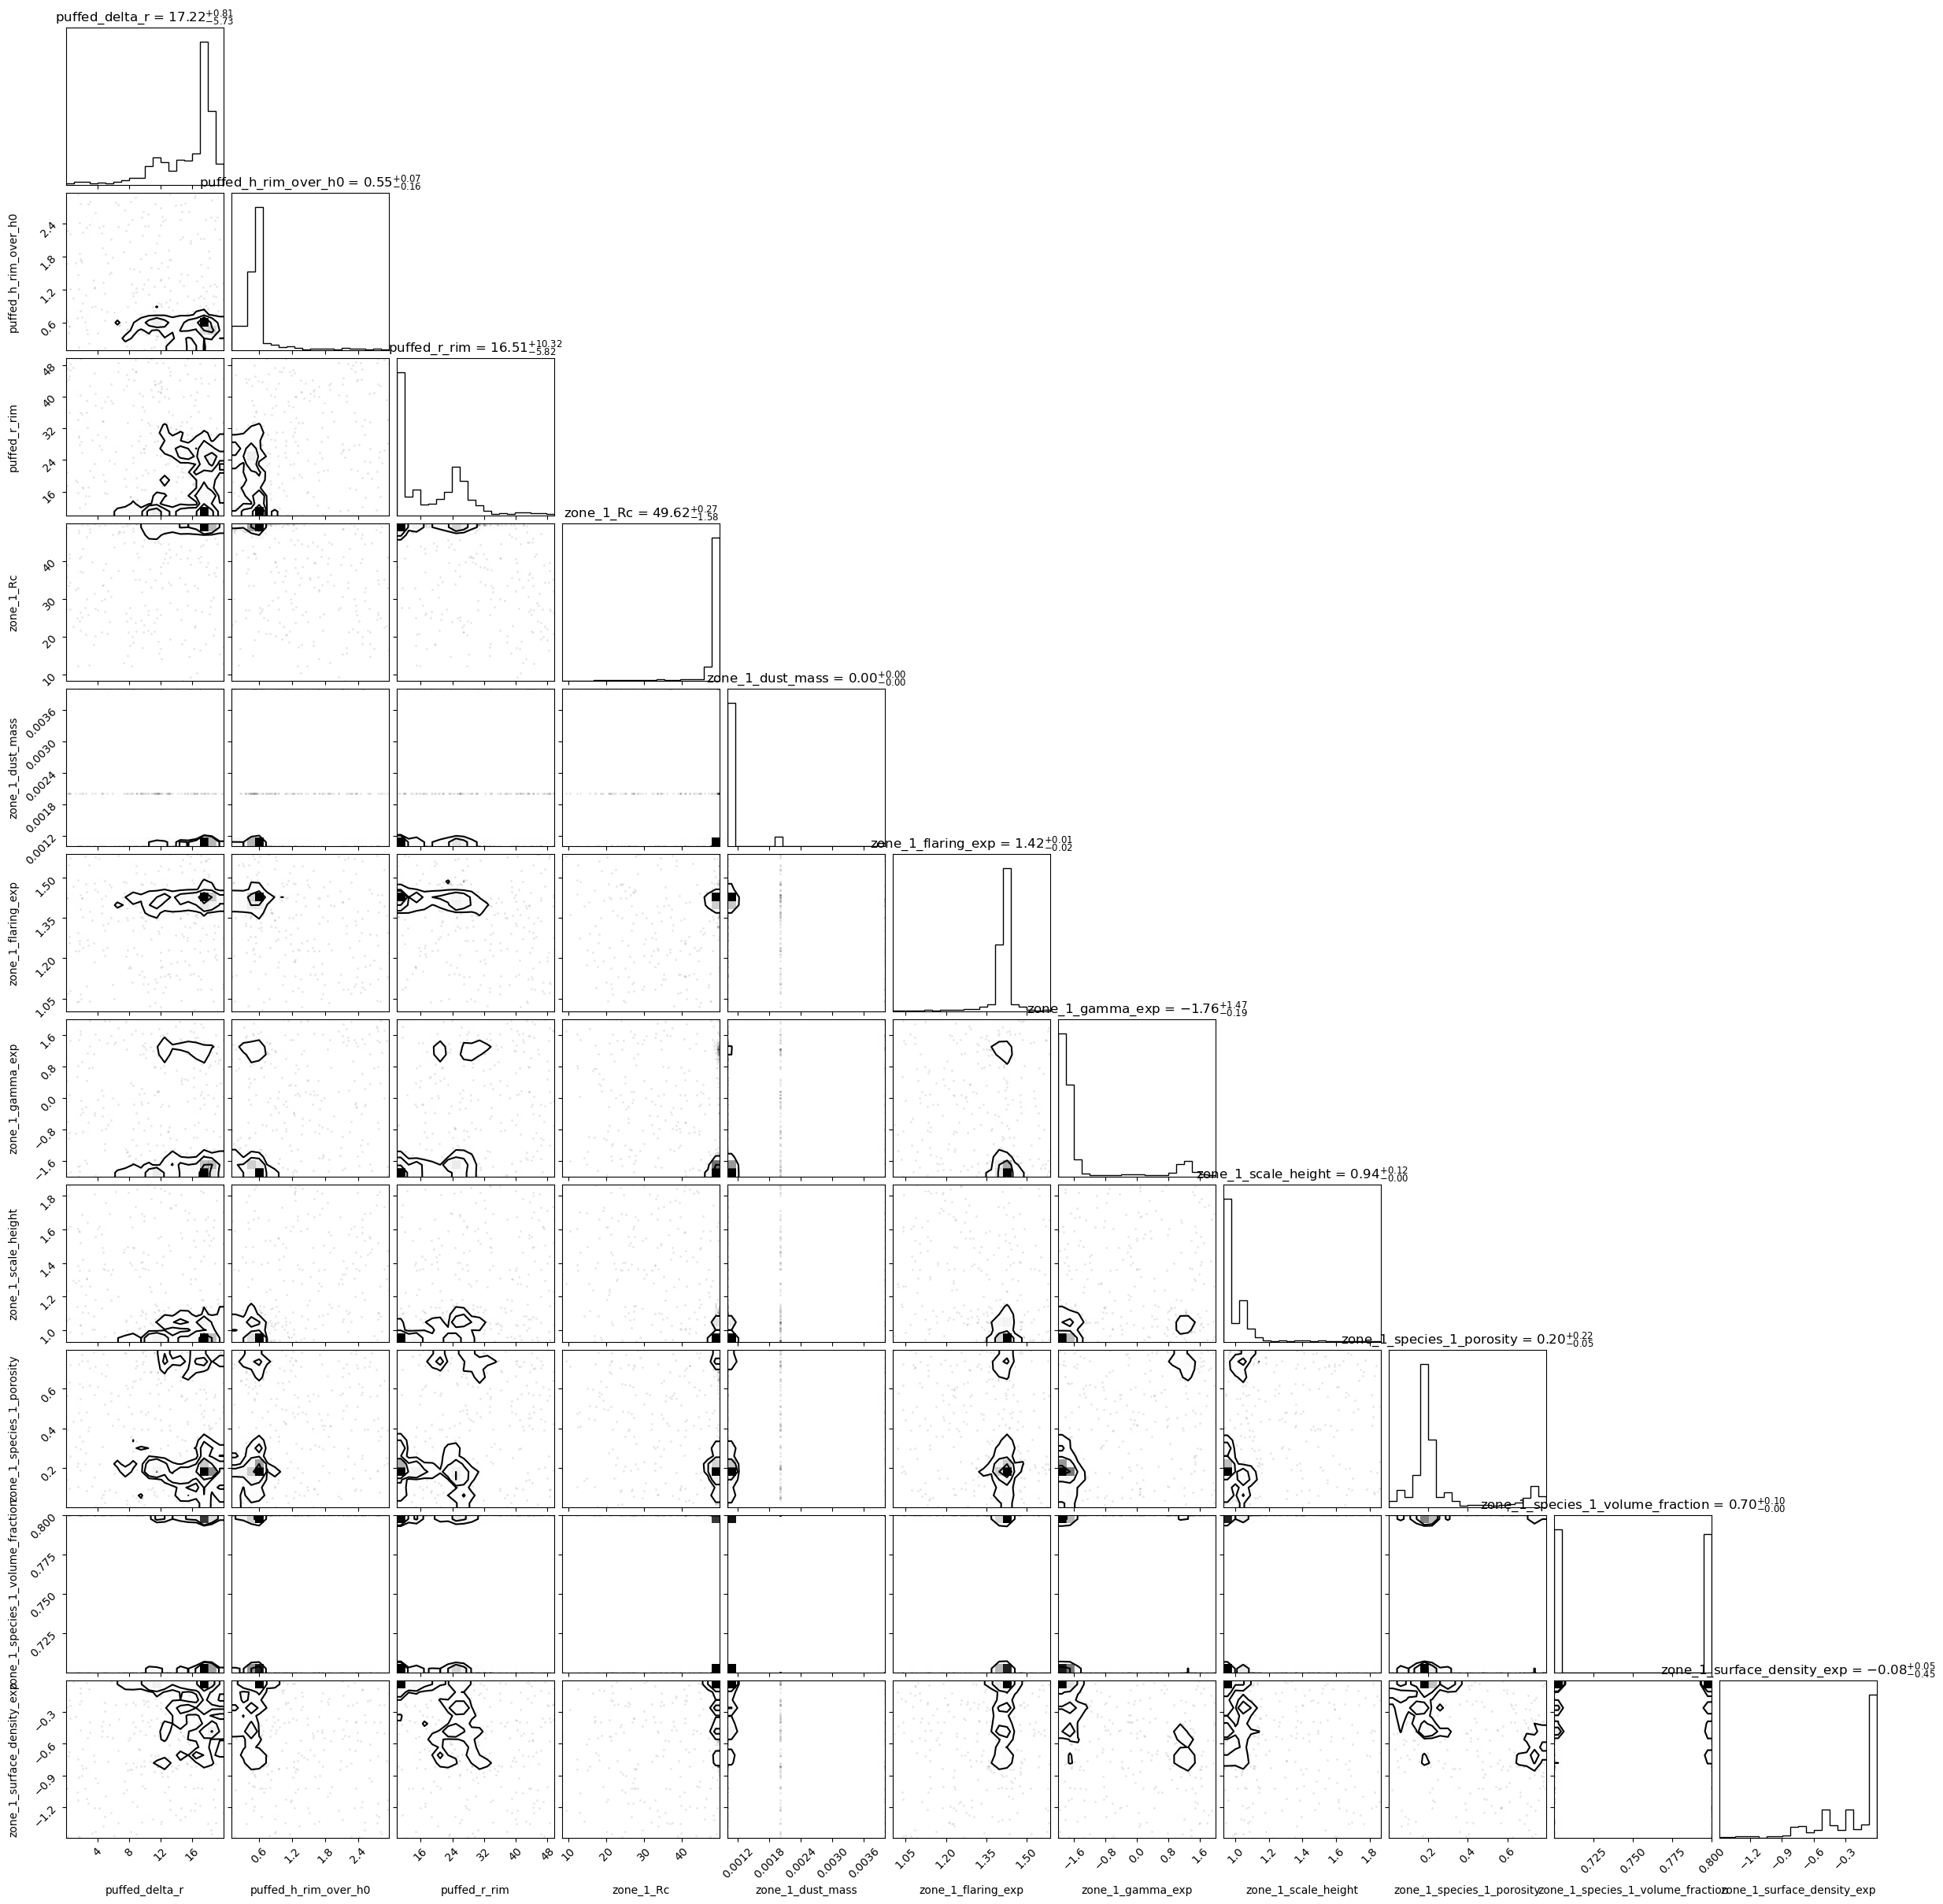

In [34]:
data = df_sel[param_cols].values

fig = corner.corner(
    data,
    labels=param_cols,
    truths=None,              # optional: known reference values
    # quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
)

fig.savefig(results_dir +"corner_all_params.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

weights = 1.0 / df_sel["cost"].values

fig = corner.corner(
    data,
    labels=param_cols,
    weights=weights,
    show_titles=True,
)
fig.savefig(results_dir +"corner_all_params_weighted.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)



In [12]:
#just one function to do it
#WORKS

def make_corner_plot(
    df,
    params,
    *,
    budget=None,
    best_quantile=0.3,
    outfile="corner.png",
):

    d = df.copy()
    if budget is not None:
        d = d[d["budget"] == budget]

    d = d.dropna(subset=["cost"])
    cost_cut = d["cost"].quantile(best_quantile)
    d = d[d["cost"] <= cost_cut]

    data = d[params].values

    fig = corner.corner(
        data,
        labels=params,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt=".3g",
    )

    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.close(fig)




In [20]:
param_cols=["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]
print(df_sel[param_cols].describe())

make_corner_plot(
    df,
    params=param_cols,
    budget=df["budget"].max(),
    outfile=results_dir+ "corner_best.png"
)


        zone_1_Rc  zone_1_flaring_exp  zone_1_dust_mass  \
count  630.000000          630.000000        630.000000   
mean    44.394151            1.382408          0.001387   
std      9.756561            0.105780          0.000845   
min      8.309043            1.002292          0.001000   
25%     44.919183            1.394293          0.001000   
50%     49.344800            1.415493          0.001000   
75%     49.872334            1.427218          0.001000   
max     49.995897            1.589043          0.004000   

       zone_1_species_1_porosity  
count                 630.000000  
mean                    0.323914  
std                     0.230900  
min                     0.002606  
25%                     0.187400  
50%                     0.202568  
75%                     0.493538  
max                     0.796862  


### Test code fro chatgpt, needs to be tested

In [16]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import corner


def runhistory_to_df(smac, cs) -> pd.DataFrame:
    """Convert SMAC runhistory to a flat dataframe with params + metadata."""
    rh = smac.runhistory
    rows = []

    # SMAC RunHistory usually behaves like a dict: key->value
    for key, val in rh.items():
        # key typically has: config_id, seed, budget, instance
        cfg = rh.get_config(key.config_id)
        d = cfg.get_dictionary()

        row = dict(d)
        row["config_id"] = getattr(key, "config_id", None)
        row["seed"] = getattr(key, "seed", None)
        row["budget"] = getattr(key, "budget", None)
        row["instance"] = getattr(key, "instance", None)

        row["cost"] = getattr(val, "cost", None)
        row["time"] = getattr(val, "time", None)
        row["cpu_time"] = getattr(val, "cpu_time", None)
        row["status"] = getattr(val, "status", None)

        # Some SMAC versions store start/end times in val.additional_info
        add = getattr(val, "additional_info", None)
        if isinstance(add, dict):
            row["starttime"] = add.get("starttime", None)
            row["endtime"] = add.get("endtime", None)

        rows.append(row)

    df = pd.DataFrame(rows)

    # Helpful sorting if endtime exists
    if "endtime" in df.columns and df["endtime"].notna().any():
        df = df.sort_values(["endtime", "budget", "cost"], ascending=[True, True, True])
    else:
        df = df.sort_values(["budget", "cost"], ascending=[True, True])

    df = df.reset_index(drop=True)
    return df


def choose_param_columns(df: pd.DataFrame) -> list[str]:
    """Pick all columns that look like model params (exclude SMAC bookkeeping)."""
    exclude = {
        "config_id", "seed", "budget", "instance",
        "cost", "time", "cpu_time", "status",
        "starttime", "endtime",
    }
    return [c for c in df.columns if c not in exclude]


def split_into_groups(params: list[str], max_per_group: int = 10) -> list[list[str]]:
    """Split parameter list into chunks to keep corner readable."""
    if len(params) <= max_per_group:
        return [params]
    groups = []
    for i in range(0, len(params), max_per_group):
        groups.append(params[i:i + max_per_group])
    return groups


def safe_corner(
    df: pd.DataFrame,
    params: list[str],
    outpath: Path,
    *,
    weights: np.ndarray | None = None,
    truths: list[float] | None = None,
    title: str | None = None,
):
    """Make one corner plot robustly, dropping NaNs and constant columns."""
    d = df.copy()

    # Keep only numeric params for corner
    numeric_params = []
    for p in params:
        if p not in d.columns:
            continue
        # coerce to numeric where possible; categorical corner plots are messy
        d[p] = pd.to_numeric(d[p], errors="coerce")
        if d[p].notna().any():
            numeric_params.append(p)

    if len(numeric_params) == 0:
        print(f"[corner] Skip {outpath.name}: no numeric params found.")
        return

    d = d.dropna(subset=numeric_params + ["cost"], how="any")
    if len(d) < 5:
        print(f"[corner] Skip {outpath.name}: too few points ({len(d)}).")
        return

    # Remove constant columns (corner can choke / be useless)
    keep = []
    for p in numeric_params:
        if d[p].nunique(dropna=True) > 1:
            keep.append(p)

    if len(keep) < 2:
        print(f"[corner] Skip {outpath.name}: <2 varying params.")
        return

    data = d[keep].to_numpy(dtype=float)

    # Align truths length if provided
    t = None
    if truths is not None:
        if len(truths) == len(params):
            # Map truths to the kept params
            truth_map = {p: v for p, v in zip(params, truths)}
            t = [truth_map[p] for p in keep]
        elif len(truths) == len(keep):
            t = truths
        else:
            print(f"[corner] Warning: truths length mismatch for {outpath.name}; ignoring truths.")
            t = None

    fig = corner.corner(
        data,
        labels=keep,
        weights=weights,
        truths=t,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt=".3g",
        title_kwargs={"fontsize": 10},
    )
    if title:
        fig.suptitle(title, fontsize=12)

    fig.savefig(outpath, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"[corner] Wrote {outpath}")


def main_corner_analysis(smac, cs, results_dir: Path):
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    df = runhistory_to_df(smac, cs)
    df.to_csv(results_dir / "trials.csv", index=False)
    print(f"[analysis] Saved trials table: {results_dir/'trials.csv'}  (N={len(df)})")

    params_all = choose_param_columns(df)
    print(f"[analysis] Detected {len(params_all)} parameter columns.")

    # Prefer max budget for “physical interpretation”
    max_budget = df["budget"].max()
    df_max = df[df["budget"] == max_budget].copy()
    df_max = df_max.dropna(subset=["cost"])
    print(f"[analysis] Max budget = {max_budget} ; N(max-budget)={len(df_max)}")

    # Prepare directories
    corner_dir = results_dir / "corner"
    corner_dir.mkdir(exist_ok=True)

    # If too many params, split into groups
    groups = split_into_groups(params_all, max_per_group=10)

    # ---- 1) Max budget: all points ----
    for gi, grp in enumerate(groups, 1):
        safe_corner(
            df_max,
            grp,
            corner_dir / f"corner_maxbudget_all_group{gi:02d}.png",
            title=f"Max budget ({max_budget}) - all trials - group {gi}",
        )

    # ---- 2) Max budget: best quantile (e.g. best 30%) ----
    best_q = 0.30
    if len(df_max) > 0:
        cut = df_max["cost"].quantile(best_q)
        df_bestq = df_max[df_max["cost"] <= cut].copy()
        print(f"[analysis] Best {int(best_q*100)}% cutoff: cost <= {cut:.6g} ; N={len(df_bestq)}")

        for gi, grp in enumerate(groups, 1):
            safe_corner(
                df_bestq,
                grp,
                corner_dir / f"corner_maxbudget_best{int(best_q*100)}pct_group{gi:02d}.png",
                title=f"Max budget ({max_budget}) - best {int(best_q*100)}% - group {gi}",
            )

    # ---- 3) Max budget: top N ----
    topN = 50
    df_top = df_max.nsmallest(topN, "cost").copy()
    print(f"[analysis] Top {topN} at max budget: N={len(df_top)}")
    for gi, grp in enumerate(groups, 1):
        safe_corner(
            df_top,
            grp,
            corner_dir / f"corner_maxbudget_top{topN}_group{gi:02d}.png",
            title=f"Max budget ({max_budget}) - top {topN} - group {gi}",
        )

    # ---- 4) Weighted by 1/cost (emphasize good models) ----
    # Use best-quantile selection + weights for stability
    if len(df_max) > 0:
        df_w = df_bestq if "df_bestq" in locals() and len(df_bestq) >= 5 else df_max.copy()
        # Avoid divide-by-zero
        w = 1.0 / np.maximum(df_w["cost"].to_numpy(dtype=float), 1e-12)

        for gi, grp in enumerate(groups, 1):
            safe_corner(
                df_w,
                grp,
                corner_dir / f"corner_maxbudget_weighted_group{gi:02d}.png",
                weights=w,
                title=f"Max budget ({max_budget}) - weighted by 1/cost - group {gi}",
            )

    # ---- 5) Per-budget diagnostic corner plots (small groups only) ----
    # These can be a lot; keep only first group by default (edit if you want all groups)
    budgets = sorted(df["budget"].dropna().unique())
    diag_dir = corner_dir / "by_budget"
    diag_dir.mkdir(exist_ok=True)

    # Only do first group by default to avoid 100s of plots
    grp = groups[0] if groups else params_all

    for b in budgets:
        df_b = df[df["budget"] == b].dropna(subset=["cost"]).copy()
        if len(df_b) < 10:
            continue
        safe_corner(
            df_b,
            grp,
            diag_dir / f"corner_budget_{b:g}.png",
            title=f"Budget {b:g} - diagnostics (group 1)",
        )

    # ---- Extra: save “trajectory” (best-so-far) table ----
    # Compute best-so-far ordering by time if available, otherwise row order
    if "endtime" in df.columns and df["endtime"].notna().any():
        df_ord = df.sort_values("endtime").copy()
    else:
        df_ord = df.copy()

    best_cost = np.inf
    keep_idx = []
    for i, row in df_ord.iterrows():
        if row["cost"] < best_cost:
            best_cost = row["cost"]
            keep_idx.append(i)

    traj_df = df_ord.loc[keep_idx].reset_index(drop=True)
    traj_df.to_csv(results_dir / "trajectory_best_so_far.csv", index=False)
    print(f"[analysis] Saved trajectory: {results_dir/'trajectory_best_so_far.csv'}  (K={len(traj_df)})")

    # Save some quick summaries
    (df.groupby("budget")["cost"].describe()
       .to_csv(results_dir / "cost_by_budget.csv"))
    print(f"[analysis] Saved cost summary: {results_dir/'cost_by_budget.csv'}")


# ---- call it ----
# Use results_dir you already created; I suggest putting plots under results_dir
main_corner_analysis(smac, cs, results_dir)


NameError: name 'smac' is not defined